In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [55]:
df = pd.read_csv("sonar data.csv", header = None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


#### Number of rows and column 

In [56]:
df.shape

(208, 61)

In [57]:
df.size

12688

In [58]:
df.describe()   # statistical measures of the data

,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
count,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,...,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000
mean,0.029164,0.038437,0.043832,0.053892,0.075202,0.104570,0.121747,0.134799,0.178003,0.208259,...,0.016069,0.013420,0.010709,0.010941,0.009290,0.008222,0.007820,0.007949,0.007941,0.006507
std,0.022991,0.032960,0.038428,0.046528,0.055552,0.059105,0.061788,0.085152,0.118387,0.134416,...,0.012008,0.009634,0.007060,0.007301,0.007088,0.005736,0.005785,0.006470,0.006181,0.005031
min,0.001500,0.000600,0.001500,0.005800,0.006700,0.010200,0.003300,0.005500,0.007500,0.011300,...,0.000000,0.000800,0.000500,0.001000,0.000600,0.000400,0.000300,0.000300,0.000100,0.000600
25%,0.013350,0.016450,0.018950,0.024375,0.038050,0.067025,0.080900,0.080425,0.097025,0.111275,...,0.008425,0.007275,0.005075,0.005375,0.004150,0.004400,0.003700,0.003600,0.003675,0.003100
50%,0.022800,0.030800,0.034300,0.044050,0.062500,0.092150,0.106950,0.112100,0.152250,0.182400,...,0.013900,0.011400,0.009550,0.009300,0.007500,0.006850,0.005950,0.005800,0.006400,0.005300
75%,0.035550,0.047950,0.057950,0.064500,0.100275,0.134125,0.154000,0.169600,0.233425,0.268700,...,0.020825,0.016725,0.014900,0.014500,0.012100,0.010575,0.010425,0.010350,0.010325,0.008525
max,0.137100,0.233900,0.305900,0.426400,0.401000,0.382300,0.372900,0.459000,0.682800,0.710600,...,0.100400,0.070900,0.039000,0.035200,0.044700,0.039400,0.035500,0.044000,0.036400,0.043900


In [59]:
df[60].value_counts()

60
M    111
R     97
Name: count, dtype: int64

- M = Mine
- R = Rock

In [60]:
df.groupby(60).mean()

,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
60,,,,,,,,,,,,,,,,,,,,,
M,0.034989,0.045544,0.050720,0.064768,0.086715,0.111864,0.128359,0.149832,0.213492,0.251022,...,0.019352,0.016014,0.011643,0.012185,0.009923,0.008914,0.007825,0.009060,0.008695,0.006930
R,0.022498,0.030303,0.035951,0.041447,0.062028,0.096224,0.114180,0.117596,0.137392,0.159325,...,0.012311,0.010453,0.009640,0.009518,0.008567,0.007430,0.007814,0.006677,0.007078,0.006024


##### Separating data and labels

In [61]:
x = df.drop(columns = 60, axis = 1)
y = df[60]

In [62]:
print(x)


         0       1       2       3       4       5       6       7       8   \
0    0.0200  0.0371  0.0428  0.0207  0.0954  0.0986  0.1539  0.1601  0.3109   
1    0.0453  0.0523  0.0843  0.0689  0.1183  0.2583  0.2156  0.3481  0.3337   
2    0.0262  0.0582  0.1099  0.1083  0.0974  0.2280  0.2431  0.3771  0.5598   
3    0.0100  0.0171  0.0623  0.0205  0.0205  0.0368  0.1098  0.1276  0.0598   
4    0.0762  0.0666  0.0481  0.0394  0.0590  0.0649  0.1209  0.2467  0.3564   
..      ...     ...     ...     ...     ...     ...     ...     ...     ...   
203  0.0187  0.0346  0.0168  0.0177  0.0393  0.1630  0.2028  0.1694  0.2328   
204  0.0323  0.0101  0.0298  0.0564  0.0760  0.0958  0.0990  0.1018  0.1030   
205  0.0522  0.0437  0.0180  0.0292  0.0351  0.1171  0.1257  0.1178  0.1258   
206  0.0303  0.0353  0.0490  0.0608  0.0167  0.1354  0.1465  0.1123  0.1945   
207  0.0260  0.0363  0.0136  0.0272  0.0214  0.0338  0.0655  0.1400  0.1843   

         9   ...      50      51      52      53   

In [63]:
print(y)

0      R
1      R
2      R
3      R
4      R
      ..
203    M
204    M
205    M
206    M
207    M
Name: 60, Length: 208, dtype: object


### Training and test data

In [64]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.1, stratify = y, random_state = 5)

In [65]:
print(x_train.shape, x_test.shape)

(187, 60) (21, 60)


# model training --> Logistic regression 

In [66]:
LogisticRegression(
    C=1.0,
    class_weight=None,
    dual=False,
    fit_intercept=True,
    intercept_scaling=1,
    l1_ratio=None,
    max_iter=100,
    multi_class='auto',
    n_jobs=None,
    penalty='l2',
    random_state=None,
    solver='lbfgs',
    tol=0.0001,
    verbose=0,
    warm_start=False
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'auto'


In [67]:
model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## Model evaluation 

In [68]:
pred_y_test = model.predict(x_test)
print(pred_y_test)

['R' 'M' 'R' 'M' 'R' 'M' 'M' 'R' 'M' 'M' 'M' 'M' 'M' 'R' 'R' 'M' 'M' 'M'
 'R' 'M' 'R']


In [69]:
pred_y_train = model.predict(x_train)
print(pred_y_train)

['M' 'M' 'M' 'R' 'R' 'M' 'R' 'R' 'M' 'M' 'R' 'M' 'M' 'R' 'R' 'M' 'M' 'M'
 'R' 'M' 'R' 'R' 'M' 'R' 'R' 'M' 'R' 'R' 'M' 'M' 'R' 'M' 'R' 'R' 'R' 'M'
 'R' 'M' 'M' 'R' 'M' 'R' 'R' 'R' 'M' 'M' 'M' 'M' 'M' 'R' 'M' 'M' 'R' 'M'
 'R' 'M' 'M' 'M' 'R' 'R' 'M' 'R' 'R' 'R' 'M' 'R' 'R' 'R' 'M' 'R' 'M' 'R'
 'R' 'R' 'M' 'R' 'R' 'M' 'M' 'M' 'M' 'M' 'R' 'R' 'R' 'M' 'M' 'M' 'M' 'R'
 'M' 'R' 'M' 'M' 'R' 'R' 'M' 'R' 'R' 'M' 'M' 'R' 'R' 'R' 'M' 'R' 'M' 'M'
 'M' 'M' 'M' 'M' 'M' 'M' 'R' 'M' 'M' 'M' 'M' 'R' 'R' 'M' 'R' 'R' 'R' 'R'
 'M' 'M' 'M' 'R' 'R' 'M' 'M' 'M' 'R' 'M' 'M' 'R' 'M' 'M' 'M' 'R' 'M' 'M'
 'M' 'R' 'M' 'M' 'M' 'R' 'R' 'M' 'R' 'R' 'M' 'R' 'M' 'M' 'R' 'M' 'M' 'R'
 'R' 'R' 'M' 'R' 'M' 'M' 'R' 'R' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'R' 'M' 'R'
 'R' 'R' 'R' 'R' 'M' 'R' 'M']


### accuracy

In [70]:
accuracy = accuracy_score(y_test, pred_y_test)
print("accuracy of the model in testing data:", accuracy)

accuracy of the model in testing data: 0.6190476190476191


In [71]:
accuracy1 = accuracy_score(y_train, pred_y_train)
print("accuracy of the model in training data:", accuracy1)

accuracy of the model in training data: 0.8288770053475936


#### making a predictive system

In [73]:

input_data = input("Enter feature values separated by comma: ")

# split by comma and convert to float
input_data = np.array(input_data.split(','), dtype=float)

# reshape for single instance
input_data_reshaped = input_data.reshape(1, -1)

prediction = model.predict(input_data_reshaped)
print(prediction)

if prediction[0] == 'R':
    print("The object is Rock")
else:
    print("The object is a Mine")


Enter feature values separated by comma:  0.0079,0.0086,0.0055,0.0250,0.0344,0.0546,0.0528,0.0958,0.1009,0.1240,0.1097,0.1215,0.1874,0.3383,0.3227,0.2723,0.3943,0.6432,0.7271,0.8673,0.9674,0.9847,0.9480,0.8036,0.6833,0.5136,0.3090,0.0832,0.4019,0.2344,0.1905,0.1235,0.1717,0.2351,0.2489,0.3649,0.3382,0.1589,0.0989,0.1089,0.1043,0.0839,0.1391,0.0819,0.0678,0.0663,0.1202,0.0692,0.0152,0.0266,0.0174,0.0176,0.0127,0.0088,0.0098,0.0019,0.0059,0.0058,0.0059,0.0032


['R']
The object is Rock


In [74]:
import matplotlib.pyplot as plt


In [75]:
cm = confusion_matrix(y_test, pred_y_test)
print(cm)


[[8 3]
 [5 5]]


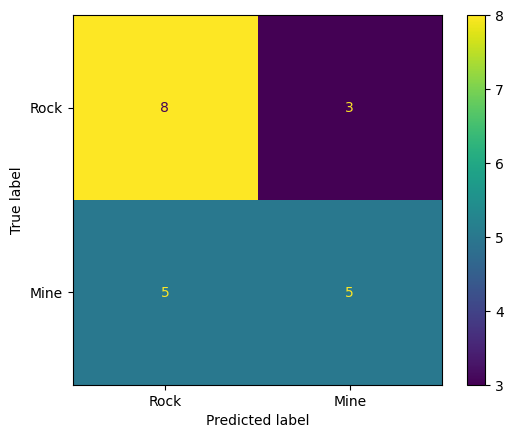

In [76]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Rock", "Mine"]
)
disp.plot()
plt.show()
